# Tools

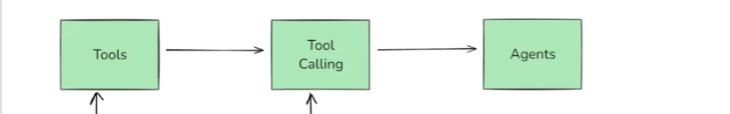

## What is Tool 
- A tool is just a python function(or API) that is packaged in a way the LLM can understand and call when needed

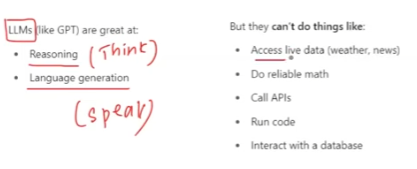

## Tools
- Built-In Tools
- Custom Tools

#### How tools fit into the agent system

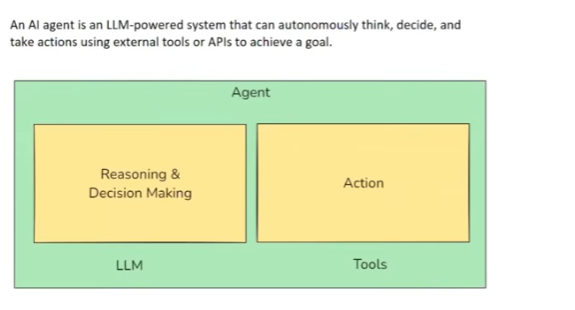

Agent = LLM + Tools

# Built-in Tools

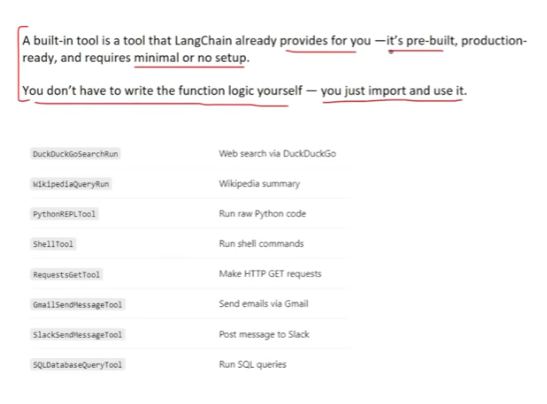

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_Tool = DuckDuckGoSearchRun()
result = search_Tool.invoke('News about NEET paper leak')
print(result)

CBI arrests journalist in NEET-UG paper leaks case ... Rs 32L for question paper: How NEET paper was leaked ... NEET's sanctity hit, says SC, in plea ... ... NEET-UG) 2024 is 'lost', the Supreme Court on Monday sought information from the National Testing Agency and the Central Bureau of Investigation (CBI) ... Home » News » NEET paper leak ... They also want to hide the paper leak scam," Animesh, a NEET aspirant from Madhya Pradesh, said. NEET-UG Paper Leak: The three-member bench, headed by Chief Justice of India DY Chandrachud, reportedly observed that there was no room for doubt ... Protest Demanding Resignation of Union Education Minister over NEET paper leak succesful in Badwel Town 4 July 2024 3:15 PM IST


In [8]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

results = shell_tool.invoke('dir')
print(results)


Executing command:
 dir
'DOSKEY' is not recognized as an internal or external command,
operable program or batch file.
 Volume in drive C is Windows
 Volume Serial Number is DC68-721D

 Directory of c:\Users\HP\Documents\Coding journeys\GenAI\genAIlearning

22-05-2026  04:24 PM    <DIR>          .
16-05-2026  03:39 PM    <DIR>          ..
28-08-2025  10:00 PM         6,028,860 Book1.pdf
19-05-2026  02:52 PM           193,172 campusX_Chains.ipynb
21-05-2026  02:07 PM           951,315 campusX_DocumentLoaders.ipynb
16-05-2026  02:38 AM           766,775 campusX_LangchainComponents.ipynb
16-05-2026  04:50 PM           612,079 campusX_LangChainModels.ipynb
18-05-2026  04:59 PM           535,619 campusX_outputparsers.ipynb
18-05-2026  12:52 PM           229,395 campusX_Prompts.ipynb
22-05-2026  02:31 PM         1,319,148 campusX_RAG.ipynb
22-05-2026  12:59 AM         1,230,351 campusX_Retrievers.ipynb
19-05-2026  10:21 PM         1,555,214 campusX_Runnables.ipynb
18-05-2026  03:06 PM       

# Custom Tools

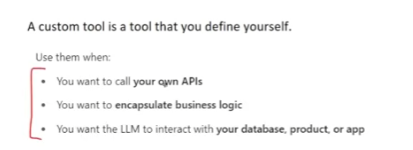

In [9]:
from langchain_core.tools import tool

In [12]:
# create a function
def mutliply(a, b):
    """Multiply two numbers"""
    return a*b

# Add type hints
def Multiply(a : int, b : int)->int:
    """ Multiply two numbers"""
    return a*b

In [13]:
# Add tool decorator
@tool
def Multiply(a : int, b : int)->int:
    """ Multiply two numbers"""
    return a*b

In [14]:
result = Multiply.invoke({'a' : 3, "b" : 5})
print(result)

15


In [16]:
print(Multiply.name)
print(Multiply.description)
print(Multiply.args)

Multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [17]:
print(Multiply.args_schema.model_json_schema())

{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'Multiply', 'type': 'object'}


## Ways to create Custom Tools

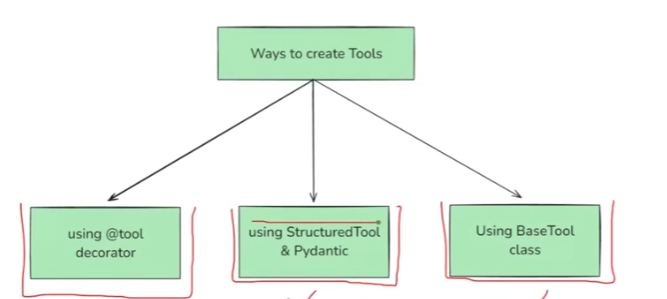

- A structure Tool in LangChain is a special type of tool where the input to the tool follows a structures schema, typically defined using a pydantic model

In [20]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [21]:
class MultiplyInput(BaseModel):
    a : int = Field(required =True, description='First number to add')
    b : int = Field(required =True, description='second number to add')

C:\Users\HP\AppData\Local\Temp\ipykernel_23660\2923527139.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a : int = Field(required =True, description='First number to add')
C:\Users\HP\AppData\Local\Temp\ipykernel_23660\2923527139.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b : int = Field(required =True, description='second number to add')


In [22]:
def MultiplyFunction(a : int, b : int) -> int:
    return a * b

In [23]:
multiply_tool = StructuredTool.from_function(
    func = MultiplyFunction,
    name = "multiply",
    description = "Multiply two numbers",
    args_schema = MultiplyInput
)

In [24]:
result = multiply_tool.invoke({'a':3, 'b':5})

print(result)

15


# using base tool class

## BaseTool

basetool is the abstract base calss for all tools in langhain. it defines the core structure and interface that any tool must follow, whether its a simple one liner or a fully customised function

All the tools ypes like @tool, structuredTool are builf on top of the bASeTool

In [26]:
from langchain_core.tools import BaseTool
from typing import Type

In [ ]:
class MultiplyInput(BaseModel):
    a : int = Field(required =True, description='First number to add')
    b : int = Field(required =True, description='second number to add')

In [28]:
class MultiplyTool(BaseTool):
    name : str = "multiply"
    description: str = 'Multiply two numbers'

    args_schema : Type[BaseModel] = MultiplyInput
    
    def _run(self, a : int, b : int) ->int :
        return a * b

In [29]:
result = multiply_tool.invoke({'a':3, 'b':5})

print(result)

15


# ToolKits

A toolkit is just a collection(bundle) of related tools that serve a common purpose - Packaged together for convenience and reusablility

In [35]:
from langchain_core.tools import tool

# Custom Tools
@tool
def add(a : int, b : int) -> int:
    """ add two numbers"""
    return a + b

@tool
def mutliply(a : int, b : int) -> int:
    """ Multiply two number"""
    return a * b

In [37]:
class MathToolkit:
    def get_tools(self):
        return [add, mutliply]

In [38]:
toolkit = MathToolkit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)

add => add two numbers
mutliply => Multiply two number
